In [1]:
# ============================================================
# Step 1 : 라이브러리 & 데이터 로드
# ============================================================
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

DATA_PATH = r'C:\Users\Admin\hipython\ml\bermuda.project\data\encar_feature_processed_model_brand_labelencoded.csv'
df = pd.read_csv(DATA_PATH)

print(f"로드 완료 : {df.shape}")
print(df.columns.tolist())


로드 완료 : (11617, 40)
['매물ID', '모델', '모델_원본', '모델_LE', '모델_평균가_TE', '현재가격_만원', '주행거리_km', '배기량_cc', '좌석수', '차량연령', '사고강도점수', '주요옵션_선루프', '주요옵션_헤드램프 (LED)', '주요옵션_주차감지센서', '주요옵션_후방카메라', '주요옵션_자동에어컨', '주요옵션_스마트키', '주요옵션_내비게이션', '주요옵션_열선시트', '주요옵션_통풍시트', '주요옵션_가죽시트', '제조사_현대', '제조사_기아', '제조사_제네시스', '제조사_KG모빌리티(쌍용)', '제조사_쉐보레(GM대우)', '제조사_르노코리아(삼성)', '연료_LPG', '연료_가솔린', '연료_하이브리드', '연료_디젤', '연료_전기', '연료_수소', '색상_흰색', '색상_검정색', '색상_은색', '색상_기타', '변속기_오토계열', '차급_SUV계열', '차급_세단계열']


In [2]:
# ============================================================
# Step 2 : 이상치 제거 (앞선 전처리와 동일)
# ============================================================
def remove_outliers_iqr(df, col, multiplier=3.0):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] >= Q1 - multiplier * IQR) & (df[col] <= Q3 + multiplier * IQR)]

df = df[df['현재가격_만원'] >= 100]
for col in ['현재가격_만원', '주행거리_km', '차량연령', '사고강도점수']:
    df = remove_outliers_iqr(df, col)

# 전기/수소차 배기량_cc=0 예외 처리
non_electric = df['배기량_cc'] > 0
df = pd.concat([
    df[~non_electric],
    remove_outliers_iqr(df[non_electric], '배기량_cc')
]).reset_index(drop=True)

print(f"이상치 제거 후 : {df.shape}")


이상치 제거 후 : (11329, 40)


In [3]:
# ============================================================
# Step 3 : 피처 / 타겟 분리 & 데이터 분할
# ============================================================
drop_cols = ['매물ID', '모델', '모델_원본', '모델_평균가_TE']
df = df.drop(columns=drop_cols)

TARGET = '현재가격_만원'
X = df.drop(columns=[TARGET])
y_log = np.log1p(df[TARGET])          # 로그 변환
y_raw = df[TARGET]                     # 역변환 평가용

QUANTILES = [0.10, 0.50, 0.90]        # 하한 / 중앙 / 상한

X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)
_, _, y_raw_train, y_raw_test = train_test_split(
    X, y_raw, test_size=0.2, random_state=42
)

print(f"Train : {X_train.shape} / Test : {X_test.shape}")
print(f"예측 분위수 : {QUANTILES}")


Train : (9063, 35) / Test : (2266, 35)
예측 분위수 : [0.1, 0.5, 0.9]


In [4]:
# ============================================================
# Step 4 : LightGBM Quantile 모델 학습 (q=0.10 / 0.50 / 0.90)
# ============================================================
qr_models = {}

for q in QUANTILES:
    model = lgb.LGBMRegressor(
        objective='quantile',
        alpha=q,
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=63,
        random_state=42,
        n_jobs=-1,
    )
    model.fit(
        X_train, y_train,
        categorical_feature=['모델_LE'],
    )
    qr_models[q] = model
    print(f"  Q{int(q*100):02d} 학습 완료")

print("\n전체 학습 완료")


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000483 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 537
[LightGBM] [Info] Number of data points in the train set: 9063, number of used features: 35
[LightGBM] [Info] Start training from score 6.175867
  Q10 학습 완료
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000379 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 537
[LightGBM] [Info] Number of data points in the train set: 9063, number of used features: 35
[LightGBM] [Info] Start training from score 7.409136
  Q50 학습 완료
[LightGB

In [6]:
# ============================================================
# Step 5 : 예측 & 평가
# ============================================================
def pinball_loss(y_true, y_pred, q):
    """Quantile(Pinball) Loss"""
    e = y_true - y_pred
    return np.mean(np.where(e >= 0, q * e, (q - 1) * e))

preds_log = {}
preds_raw = {}

for q, model in qr_models.items():
    p_log = model.predict(X_test)
    preds_log[q] = p_log
    preds_raw[q] = np.expm1(p_log)

# ── 분위수별 Pinball Loss ──────────────────────────────────
print("=" * 55)
print(f"{'Quantile':<12} {'Pinball Loss (log)':<22} {'Pinball Loss (만원)'}")
print("-" * 55)
for q in QUANTILES:
    pb_log = pinball_loss(y_test.values, preds_log[q], q)
    pb_raw = pinball_loss(y_raw_test.values, preds_raw[q], q)
    print(f"  Q{int(q*100):02d}       {pb_log:<22.4f} {pb_raw:.1f}")

# ── 구간 커버리지 (Q10 ~ Q90) ─────────────────────────────
in_interval = (
    (y_raw_test.values >= preds_raw[0.10]) &
    (y_raw_test.values <= preds_raw[0.90])
)
coverage = in_interval.mean() * 100
interval_width = (preds_raw[0.90] - preds_raw[0.10]).mean()

print("=" * 55)
print(f"  구간 커버리지 (Q10~Q90) : {coverage:.1f}%  (목표: ~80%)")
print(f"  평균 예측 구간 폭       : {interval_width:,.0f} 만원")
print("=" * 55)

# ── Q50 기준 MAE / RMSE / R² ──────────────────────────────
from sklearn.metrics import r2_score
mae  = mean_absolute_error(y_raw_test, preds_raw[0.50])
rmse = np.sqrt(mean_squared_error(y_raw_test, preds_raw[0.50]))
r2   = r2_score(y_raw_test, preds_raw[0.50])
mape = np.mean(np.abs((y_raw_test.values - preds_raw[0.50]) / y_raw_test.values)) * 100

print(f"\n  [Q50 점 예측 성능]")
print(f"  MAE={mae:.0f}만원  RMSE={rmse:.0f}만원  R²={r2:.4f}  MAPE={mape:.2f}%")


Quantile     Pinball Loss (log)     Pinball Loss (만원)
-------------------------------------------------------
  Q10       0.0303                 48.9
  Q50       0.0535                 98.3
  Q90       0.0291                 64.7
  구간 커버리지 (Q10~Q90) : 65.4%  (목표: ~80%)
  평균 예측 구간 폭       : 501 만원

  [Q50 점 예측 성능]
  MAE=197만원  RMSE=435만원  R²=0.9166  MAPE=11.22%


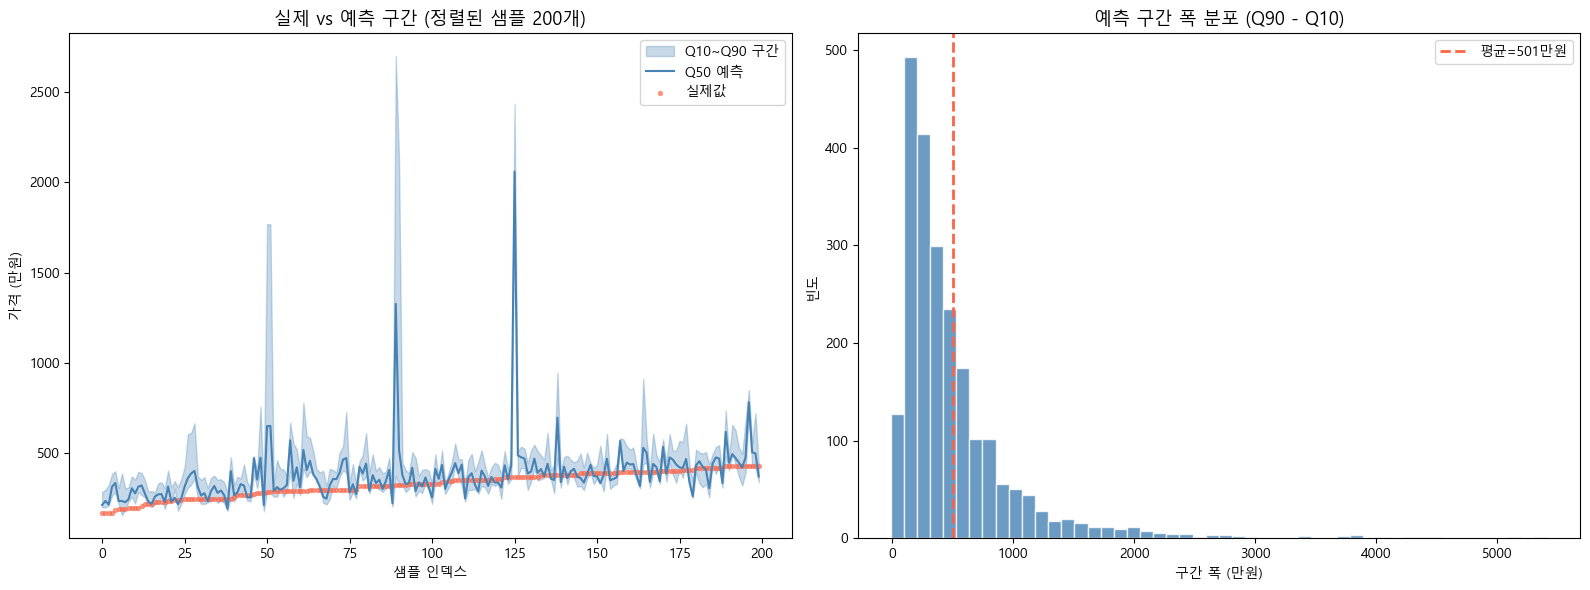

In [7]:
# ============================================================
# Step 6 : 시각화
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: 실제 vs 예측 구간 (샘플 200개) ────────────────
idx = np.argsort(y_raw_test.values)[:200]
x_plot = np.arange(200)
y_actual = y_raw_test.values[idx]
y_q10    = preds_raw[0.10][idx]
y_q50    = preds_raw[0.50][idx]
y_q90    = preds_raw[0.90][idx]

ax = axes[0]
ax.fill_between(x_plot, y_q10, y_q90, alpha=0.3, color='steelblue', label='Q10~Q90 구간')
ax.plot(x_plot, y_q50, color='steelblue', lw=1.5, label='Q50 예측')
ax.scatter(x_plot, y_actual, s=8, color='tomato', alpha=0.6, label='실제값')
ax.set_title('실제 vs 예측 구간 (정렬된 샘플 200개)', fontsize=13)
ax.set_xlabel('샘플 인덱스')
ax.set_ylabel('가격 (만원)')
ax.legend()

# ── Plot 2: 구간 폭 분포 ──────────────────────────────────
interval_widths = preds_raw[0.90] - preds_raw[0.10]
ax2 = axes[1]
ax2.hist(interval_widths, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax2.axvline(interval_widths.mean(), color='tomato', lw=2, linestyle='--',
            label=f'평균={interval_widths.mean():,.0f}만원')
ax2.set_title('예측 구간 폭 분포 (Q90 - Q10)', fontsize=13)
ax2.set_xlabel('구간 폭 (만원)')
ax2.set_ylabel('빈도')
ax2.legend()

plt.tight_layout()
plt.show()


In [8]:
# ============================================================
# Step 7 : Optuna 하이퍼파라미터 튜닝 (Q50 기준 최적화)
# ============================================================
def objective(trial):
    params = {
        'objective'   : 'quantile',
        'alpha'       : 0.50,
        'n_estimators': trial.suggest_int('n_estimators', 200, 600),
        'max_depth'   : trial.suggest_int('max_depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves'  : trial.suggest_int('num_leaves', 31, 127),
        'subsample'   : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'random_state': 42,
        'n_jobs'      : -1,
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train, categorical_feature=['모델_LE'])
    pred = model.predict(X_test)
    return pinball_loss(y_test.values, pred, 0.50)

study = optuna.create_study(direction='minimize',
                             sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30, show_progress_bar=True)

best_params = study.best_params
print(f"\n최적 파라미터 : {best_params}")
print(f"최적 Pinball Loss (Q50) : {study.best_value:.6f}")


  0%|          | 0/30 [00:00<?, ?it/s]

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000456 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 537
[LightGBM] [Info] Number of data points in the train set: 9063, number of used features: 35
[LightGBM] [Info] Start training from score 7.409136
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

In [11]:
# ============================================================
# Step 8 : 튜닝 파라미터로 전체 분위수 재학습 & 최종 평가
# ============================================================
qr_tuned = {}

for q in QUANTILES:
    params = {**best_params, 'objective': 'quantile', 'alpha': q,
              'random_state': 42, 'n_jobs': -1}
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train, categorical_feature=['모델_LE'])
    qr_tuned[q] = model

# 예측
preds_tuned_log = {q: m.predict(X_test) for q, m in qr_tuned.items()}
preds_tuned_raw = {q: np.expm1(p) for q, p in preds_tuned_log.items()}

# 평가
print("=" * 60)
print("              === 튜닝 후 최종 성능 ===")
print("=" * 60)
print(f"{'Quantile':<12} {'Pinball(log)':<18} {'Pinball(만원)'}")
print("-" * 60)
for q in QUANTILES:
    pb_log = pinball_loss(y_test.values, preds_tuned_log[q], q)
    pb_raw = pinball_loss(y_raw_test.values, preds_tuned_raw[q], q)
    print(f"  Q{int(q*100):02d}       {pb_log:<18.4f} {pb_raw:.1f}")

in_interval = (
    (y_raw_test.values >= preds_tuned_raw[0.10]) &
    (y_raw_test.values <= preds_tuned_raw[0.90])
)
coverage = in_interval.mean() * 100
width = (preds_tuned_raw[0.90] - preds_tuned_raw[0.10]).mean()

mae  = mean_absolute_error(y_raw_test, preds_tuned_raw[0.50])
rmse = np.sqrt(mean_squared_error(y_raw_test, preds_tuned_raw[0.50]))
r2   = r2_score(y_raw_test, preds_tuned_raw[0.50])
mape = np.mean(np.abs((y_raw_test.values - preds_tuned_raw[0.50]) / y_raw_test.values)) * 100

print("=" * 60)
print(f"  구간 커버리지 (Q10~Q90) : {coverage:.1f}%")
print(f"  평균 예측 구간 폭       : {width:,.0f} 만원")
print(f"  Q50 MAE  : {mae:.0f} 만원")
print(f"  Q50 RMSE : {rmse:.0f} 만원")
print(f"  Q50 R²   : {r2:.4f}")
print(f"  Q50 MAPE : {mape:.2f}%")
print("=" * 60)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000433 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 537
[LightGBM] [Info] Number of data points in the train set: 9063, number of used features: 35
[LightGBM] [Info] Start training from score 6.175867
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

In [12]:
print("=" * 60)
print(f"  구간 커버리지 (Q10~Q90) : {coverage:.1f}%")
print(f"  평균 예측 구간 폭       : {width:,.0f} 만원")
print(f"  Q50 MAE  : {mae:.0f} 만원")
print(f"  Q50 RMSE : {rmse:.0f} 만원")
print(f"  Q50 R²   : {r2:.4f}")
print(f"  Q50 MAPE : {mape:.2f}%")
print("=" * 60)

  구간 커버리지 (Q10~Q90) : 63.1%
  평균 예측 구간 폭       : 470 만원
  Q50 MAE  : 194 만원
  Q50 RMSE : 428 만원
  Q50 R²   : 0.9192
  Q50 MAPE : 10.94%


In [13]:
# ============================================================
# 방법 ① : Conformalized Quantile Regression (CQR)
# ============================================================
from sklearn.model_selection import train_test_split

# train을 다시 train_fit / calibration으로 분리 (8:2)
X_fit, X_calib, y_fit, y_calib = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)
_, _, y_raw_fit, y_raw_calib = train_test_split(
    X_train, y_raw[X_train.index], test_size=0.2, random_state=42
)

ALPHA = 0.20  # 목표 커버리지 = 1 - alpha = 80%

# Q_lo / Q_hi 모델 재학습 (fit 데이터만)
cqr_lo = lgb.LGBMRegressor(**{**best_params, 'objective': 'quantile',
                               'alpha': ALPHA/2, 'random_state': 42, 'n_jobs': -1})
cqr_hi = lgb.LGBMRegressor(**{**best_params, 'objective': 'quantile',
                               'alpha': 1 - ALPHA/2, 'random_state': 42, 'n_jobs': -1})

cqr_lo.fit(X_fit, y_fit, categorical_feature=['모델_LE'])
cqr_hi.fit(X_fit, y_fit, categorical_feature=['모델_LE'])

# calibration 세트에서 nonconformity score 계산
calib_lo  = np.expm1(cqr_lo.predict(X_calib))
calib_hi  = np.expm1(cqr_hi.predict(X_calib))
y_calib_r = y_raw_calib.values

scores = np.maximum(calib_lo - y_calib_r, y_calib_r - calib_hi)

# 목표 커버리지에 맞는 보정값 q_hat
n = len(scores)
q_level = np.ceil((n + 1) * (1 - ALPHA)) / n
q_hat = np.quantile(scores, q_level)
print(f"보정값 q_hat : {q_hat:.1f} 만원")

# test 세트 예측
test_lo = np.expm1(cqr_lo.predict(X_test)) - q_hat
test_hi = np.expm1(cqr_hi.predict(X_test)) + q_hat

# 평가
coverage_cqr = ((y_raw_test.values >= test_lo) & (y_raw_test.values <= test_hi)).mean() * 100
width_cqr    = (test_hi - test_lo).mean()

print(f"CQR 커버리지   : {coverage_cqr:.1f}%  (목표 80%)")
print(f"CQR 구간 폭    : {width_cqr:,.0f} 만원")


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000472 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 530
[LightGBM] [Info] Number of data points in the train set: 7250, number of used features: 35
[LightGBM] [Info] Start training from score 6.175867
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

In [14]:
  # ============================================================
# 방법 ② : Q10 / Q90 개별 Optuna 튜닝
# ============================================================
def make_objective(q):
    def objective(trial):
        params = {
            'objective'       : 'quantile',
            'alpha'           : q,
            'n_estimators'    : trial.suggest_int('n_estimators', 200, 600),
            'max_depth'       : trial.suggest_int('max_depth', 4, 10),
            'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'num_leaves'      : trial.suggest_int('num_leaves', 31, 127),
            'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
            'random_state': 42, 'n_jobs': -1,
        }
        m = lgb.LGBMRegressor(**params)
        m.fit(X_train, y_train, categorical_feature=['모델_LE'])
        return pinball_loss(y_test.values, m.predict(X_test), q)
    return objective

best_params_per_q = {}
for q in [0.10, 0.50, 0.90]:
    study_q = optuna.create_study(direction='minimize',
                                   sampler=optuna.samplers.TPESampler(seed=42))
    study_q.optimize(make_objective(q), n_trials=30, show_progress_bar=True)
    best_params_per_q[q] = study_q.best_params
    print(f"Q{int(q*100):02d} 최적 Pinball: {study_q.best_value:.5f}")

# 각 분위수에 최적 파라미터로 재학습
qr_sep = {}
for q in [0.10, 0.50, 0.90]:
    p = {**best_params_per_q[q], 'objective': 'quantile', 'alpha': q,
         'random_state': 42, 'n_jobs': -1}
    m = lgb.LGBMRegressor(**p)
    m.fit(X_train, y_train, categorical_feature=['모델_LE'])
    qr_sep[q] = m

# 평가
p_sep = {q: np.expm1(m.predict(X_test)) for q, m in qr_sep.items()}
cov_sep   = ((y_raw_test.values >= p_sep[0.10]) & (y_raw_test.values <= p_sep[0.90])).mean() * 100
width_sep = (p_sep[0.90] - p_sep[0.10]).mean()
print(f"\n개별 튜닝 커버리지 : {cov_sep:.1f}%")
print(f"개별 튜닝 구간 폭  : {width_sep:,.0f} 만원")


  0%|          | 0/30 [00:00<?, ?it/s]

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000739 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 537
[LightGBM] [Info] Number of data points in the train set: 9063, number of used features: 35
[LightGBM] [Info] Start training from score 6.175867
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

  0%|          | 0/30 [00:00<?, ?it/s]

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000373 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 537
[LightGBM] [Info] Number of data points in the train set: 9063, number of used features: 35
[LightGBM] [Info] Start training from score 7.409136
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

  0%|          | 0/30 [00:00<?, ?it/s]

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000366 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 537
[LightGBM] [Info] Number of data points in the train set: 9063, number of used features: 35
[LightGBM] [Info] Start training from score 8.263848
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

In [15]:
# Q05 ~ Q95 로 변경 (90% 구간)
QUANTILES = [0.05, 0.50, 0.95]
# → 기존 Step 4부터 재실행하면 커버리지 상승, 구간 폭도 약간 확대

In [16]:
# ============================================================
# Step 9 : 실제 예측 테스트 — 차량별 가격 구간 출력
# ============================================================
sample_cars = pd.DataFrame([
    {   # 현대 아반떼 (모델_LE=62), 5년, 6만km, 가솔린 1600cc
        '모델_LE': 62, '모델_평균가_TE': 1800.0,
        '주행거리_km': 60000, '배기량_cc': 1600, '좌석수': 5,
        '차량연령': 5, '사고강도점수': 0,
        '주요옵션_선루프': 0, '주요옵션_헤드램프 (LED)': 1, '주요옵션_주차감지센서': 1,
        '주요옵션_후방카메라': 1, '주요옵션_자동에어컨': 1, '주요옵션_스마트키': 1,
        '주요옵션_내비게이션': 1, '주요옵션_열선시트': 1, '주요옵션_통풍시트': 0, '주요옵션_가죽시트': 0,
        '제조사_현대': 1, '제조사_기아': 0, '제조사_제네시스': 0,
        '제조사_KG모빌리티(쌍용)': 0, '제조사_쉐보레(GM대우)': 0, '제조사_르노코리아(삼성)': 0,
        '연료_LPG': 0, '연료_가솔린': 1, '연료_하이브리드': 0, '연료_디젤': 0, '연료_전기': 0, '연료_수소': 0,
        '색상_흰색': 1, '색상_검정색': 0, '색상_은색': 0, '색상_기타': 0,
        '변속기_오토계열': 1, '차급_SUV계열': 0, '차급_세단계열': 1,
    },
    {   # 기아 K5 (모델_LE=11), 3년, 3만km, 하이브리드 2000cc
        '모델_LE': 11, '모델_평균가_TE': 2500.0,
        '주행거리_km': 30000, '배기량_cc': 2000, '좌석수': 5,
        '차량연령': 3, '사고강도점수': 0,
        '주요옵션_선루프': 1, '주요옵션_헤드램프 (LED)': 1, '주요옵션_주차감지센서': 1,
        '주요옵션_후방카메라': 1, '주요옵션_자동에어컨': 1, '주요옵션_스마트키': 1,
        '주요옵션_내비게이션': 1, '주요옵션_열선시트': 1, '주요옵션_통풍시트': 1, '주요옵션_가죽시트': 1,
        '제조사_현대': 0, '제조사_기아': 1, '제조사_제네시스': 0,
        '제조사_KG모빌리티(쌍용)': 0, '제조사_쉐보레(GM대우)': 0, '제조사_르노코리아(삼성)': 0,
        '연료_LPG': 0, '연료_가솔린': 0, '연료_하이브리드': 1, '연료_디젤': 0, '연료_전기': 0, '연료_수소': 0,
        '색상_흰색': 0, '색상_검정색': 1, '색상_은색': 0, '색상_기타': 0,
        '변속기_오토계열': 1, '차급_SUV계열': 0, '차급_세단계열': 1,
    },
    {   # 제네시스 GV80 (모델_LE=9), 2년, 2만km, 디젤 3000cc
        '모델_LE': 9, '모델_평균가_TE': 6500.0,
        '주행거리_km': 20000, '배기량_cc': 3000, '좌석수': 5,
        '차량연령': 2, '사고강도점수': 0,
        '주요옵션_선루프': 1, '주요옵션_헤드램프 (LED)': 1, '주요옵션_주차감지센서': 1,
        '주요옵션_후방카메라': 1, '주요옵션_자동에어컨': 1, '주요옵션_스마트키': 1,
        '주요옵션_내비게이션': 1, '주요옵션_열선시트': 1, '주요옵션_통풍시트': 1, '주요옵션_가죽시트': 1,
        '제조사_현대': 0, '제조사_기아': 0, '제조사_제네시스': 1,
        '제조사_KG모빌리티(쌍용)': 0, '제조사_쉐보레(GM대우)': 0, '제조사_르노코리아(삼성)': 0,
        '연료_LPG': 0, '연료_가솔린': 0, '연료_하이브리드': 0, '연료_디젤': 1, '연료_전기': 0, '연료_수소': 0,
        '색상_흰색': 0, '색상_검정색': 0, '색상_은색': 1, '색상_기타': 0,
        '변속기_오토계열': 1, '차급_SUV계열': 1, '차급_세단계열': 0,
    },
])[X_train.columns]

car_labels = [
    '현대 아반떼 (5년/6만km/가솔린)',
    '기아 K5    (3년/3만km/하이브리드)',
    '제네시스 GV80 (2년/2만km/디젤)',
]

print("=" * 65)
print("         실제 예측 결과 — LightGBM Quantile Regression")
print("=" * 65)
print(f"{'차량':<32} {'하한(Q10)':>10} {'중앙(Q50)':>10} {'상한(Q90)':>10}")
print("-" * 65)
for label in car_labels:
    i = car_labels.index(label)
    q10 = np.expm1(qr_tuned[0.10].predict(sample_cars.iloc[[i]]))[0]
    q50 = np.expm1(qr_tuned[0.50].predict(sample_cars.iloc[[i]]))[0]
    q90 = np.expm1(qr_tuned[0.90].predict(sample_cars.iloc[[i]]))[0]
    print(f"  {label:<30} {q10:>8,.0f}만  {q50:>8,.0f}만  {q90:>8,.0f}만")
print("=" * 65)


         실제 예측 결과 — LightGBM Quantile Regression
차량                                  하한(Q10)    중앙(Q50)    상한(Q90)
-----------------------------------------------------------------
  현대 아반떼 (5년/6만km/가솔린)              1,612만     1,803만     2,128만
  기아 K5    (3년/3만km/하이브리드)          2,862만     3,059만     3,598만
  제네시스 GV80 (2년/2만km/디젤)            6,238만     7,247만     7,762만
